In [45]:
import os
import wave

import numpy as np
import librosa
from scipy.io import wavfile
import sounddevice as sd

In [86]:
base_dir_audio_data = os.path.join("..", "audio_data")
path_to_file = os.path.join(base_dir_audio_data, "fan", "id_00", "normal", "00000010.wav")

In [87]:
#samplerate, data = wavfile.read(path_to_file)
# Load the file using librosa
data, samplerate = librosa.load(path_to_file, sr=None, mono=True)
data = data.T  # Transpose to get shape (n_samples, n_channels)

In [88]:
print(f"Data type: {data.dtype}")

Data type: float32


In [89]:
n_channels = data.shape[1] if len(data.shape) > 1 else 1
duration = data.shape[0] / samplerate
print(f"Sample Rate: {samplerate} Hz")
print(f"Number of Channels: {n_channels}")
print(f"Duration: {duration:.2f} seconds")

Sample Rate: 16000 Hz
Number of Channels: 1
Duration: 10.00 seconds


In [90]:
data.shape

(160000,)

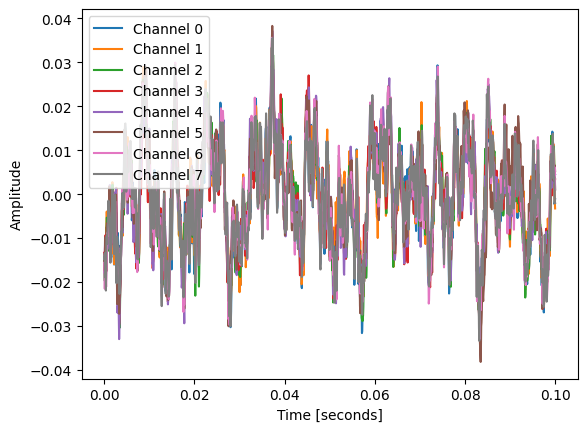

In [60]:
# plot the waveform
import matplotlib.pyplot as plt

def plot_waveform(data, samplerate, chunk_from=0, chunk_to=1000):

    time = np.arange(data.shape[0]) / samplerate
    n_channels = data.shape[1] if len(data.shape) > 1 else 1
    plt.plot(time[chunk_from:chunk_to], data[chunk_from:chunk_to], label=[f"Channel {i}" for i in range(n_channels)])
    plt.legend()
    plt.xlabel("Time [seconds]")
    plt.ylabel("Amplitude")
    plt.show()

plot_waveform(data, samplerate, chunk_from=0, chunk_to=1600)

In [7]:
with wave.open(path_to_file, 'rb') as wav_file:
    num_channels = wav_file.getnchannels()
    sample_width = wav_file.getsampwidth()
    frame_rate = wav_file.getframerate()
    n_frames = wav_file.getnframes()

    raw_data = wav_file.readframes(n_frames)

    dtype_map = {1: np.int8, 2: np.int16, 4: np.int32}
    samples = np.frombuffer(raw_data, dtype=dtype_map[sample_width])
    samples = samples.reshape(-1, num_channels)

    # Mix down to stereo
    mono = samples.mean(axis=1).astype(dtype_map[sample_width])
    stereo = np.column_stack([mono, mono])

    sd.play(stereo, samplerate=frame_rate)
    sd.wait()  # Block until playback is finished


In [8]:
wavfile.write(os.path.join(base_dir_audio_data, "fan_stereo.wav"), samplerate, stereo)

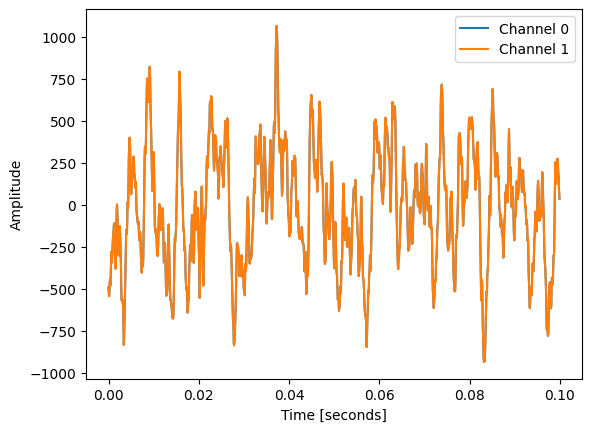

In [9]:
# Plot the stereo waveform
plot_waveform(stereo, samplerate, chunk_from=0, chunk_to=1600)

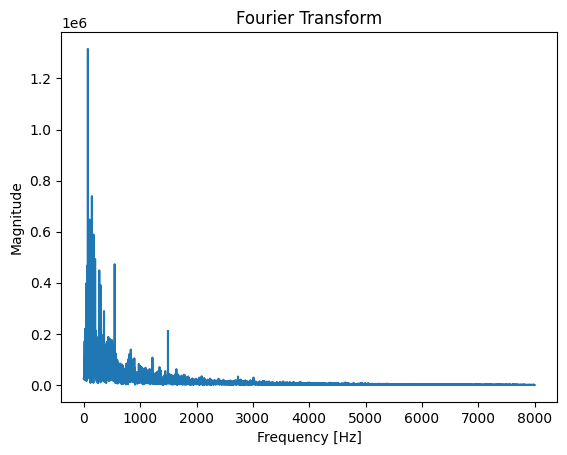

In [12]:
# Calculate the fourier transform of the audio signal
from scipy.fft import rfft, rfftfreq

def get_fourier_transform(signal, samplerate):
    """
    Compute the Fourier transform of a signal

    :param signal: Signal to be transformed
    :param samplerate: Sampling rate of the signal. Used to compute the sample frequencies.
    :return: Tuple of the transformed signal and sample frequencies.
    """

    n_samples = signal.shape[0]
    spectrum = rfft(signal)
    freq = np.fft.rfftfreq(n_samples, 1 / samplerate)

    return spectrum, freq

def plot_fourier_transform(data, samplerate, chunk_from=0, chunk_to=1000):

    signal = data[chunk_from:chunk_to]
    yf, xf = get_fourier_transform(signal, samplerate)

    plt.plot(xf, np.abs(yf))
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Magnitude")
    plt.title("Fourier Transform")
    plt.show()

averaged_signal = stereo.mean(axis=1)
plot_fourier_transform(averaged_signal, samplerate, chunk_from=0, chunk_to=16000)

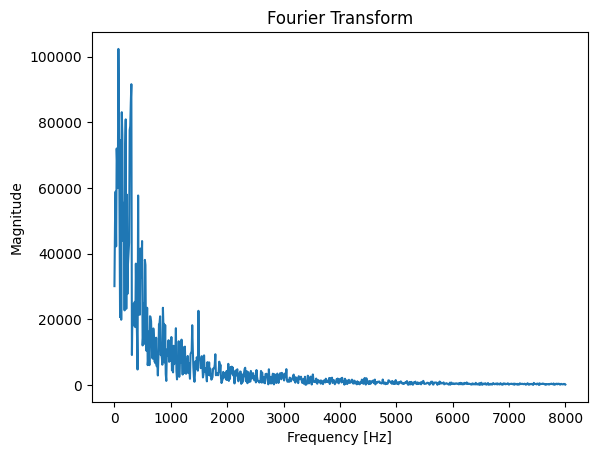

In [13]:
plot_fourier_transform(averaged_signal, samplerate, chunk_from=0, chunk_to=1600)


In [30]:
def apply_low_pass_filter(signal, samplerate, cutoff_freq):
    """
    Apply a low-pass filter to the signal by zeroing out frequencies above the cutoff frequency.

    :param signal: Input signal to be filtered
    :param samplerate: Sampling rate of the signal. Used to compute the sample frequencies.
    :param cutoff_freq: Cutoff frequency for the low-pass filter
    :return: Filtered signal in the time domain
    """

    spectrum, freq = get_fourier_transform(signal, samplerate)

    # Zero out frequencies above the cutoff frequency
    spectrum[freq > cutoff_freq] = 0

    # Inverse Fourier transform to get the filtered signal back in the time domain
    filtered_signal = np.fft.irfft(spectrum).astype(signal.dtype)

    return filtered_signal

In [39]:
# Remove high frequency components using a low-pass filter
cutoff_freq = 1000  # 2 kHz
filtered_signal = apply_low_pass_filter(averaged_signal, samplerate, cutoff_freq)


In [40]:
# Filter stereo signal by applying the low-pass filter to each channel separately
filtered_stereo = np.column_stack([
    apply_low_pass_filter(stereo[:, 0], samplerate, cutoff_freq),
    apply_low_pass_filter(stereo[:, 1], samplerate, cutoff_freq)
])

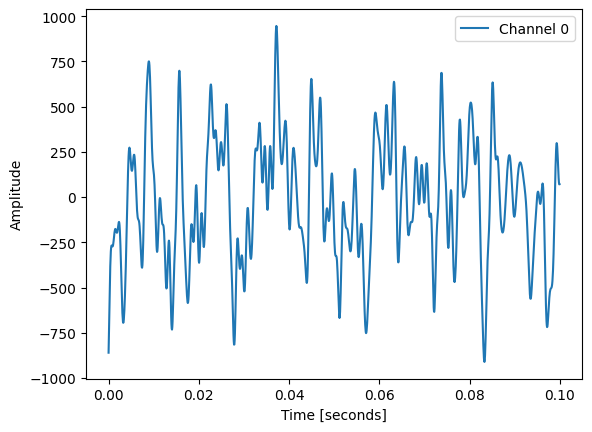

In [41]:
# Plot the filtered signal
plot_waveform(filtered_signal, samplerate, chunk_from=0, chunk_to=1600)

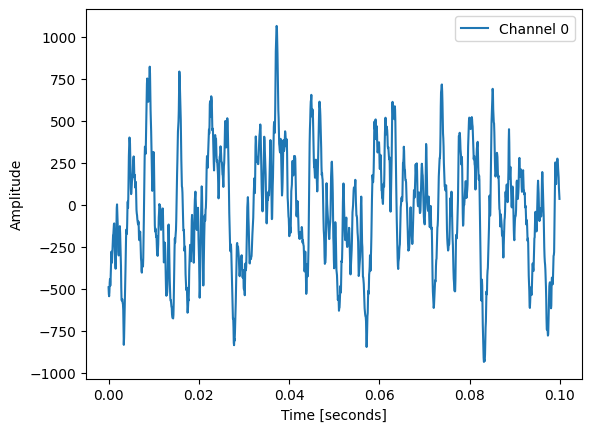

In [42]:
plot_waveform(data.mean(axis=1), samplerate, chunk_from=0, chunk_to=1600)


In [43]:
# Play the original and filtered signals
print("Playing original signal...")
sd.play(averaged_signal.astype(np.int16), samplerate)
sd.wait()
print("Playing filtered signal...")
sd.play(filtered_signal.astype(np.int16), samplerate)

Playing original signal...
Playing filtered signal...


In [44]:
# play original stereo signal
print("Playing original stereo signal...")
sd.play(stereo, samplerate)
sd.wait()
print("Playing filtered stereo signal...")
sd.play(filtered_stereo, samplerate)

Playing original stereo signal...
Playing filtered stereo signal...


array([[ -490,  -490],
       [ -531,  -531],
       [ -543,  -543],
       ...,
       [-1113, -1113],
       [-1159, -1159],
       [-1222, -1222]], shape=(160000, 2), dtype=int16)

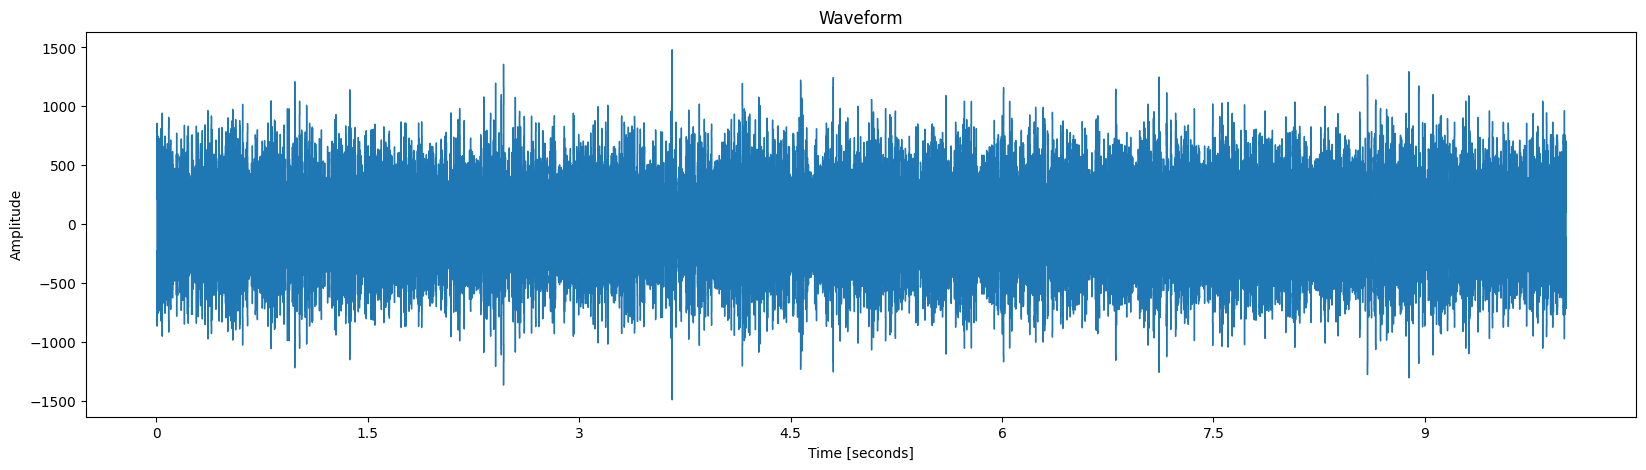

In [67]:
# Plot waveform with librosa
plt.figure(figsize=(20,5))
librosa.display.waveshow(filtered_signal, sr=samplerate)
plt.xlabel("Time [seconds]")
plt.ylabel("Amplitude")
plt.title("Waveform")
plt.show()

In [68]:
data.shape

(160000,)

In [78]:
# Create a spectrogram of the filtered signal
# number of samples in a window for the spectrogram
n_fft = 4096
# how many samples to shift the window at each step
hop_length = 1024

# Compute the spectrogram with short-time Fourier transform (STFT)
audio_stft = librosa.stft(data, n_fft=n_fft, hop_length=hop_length)
# Convert the complex-valued STFT to magnitude
audio_spectrogram = np.abs(audio_stft)


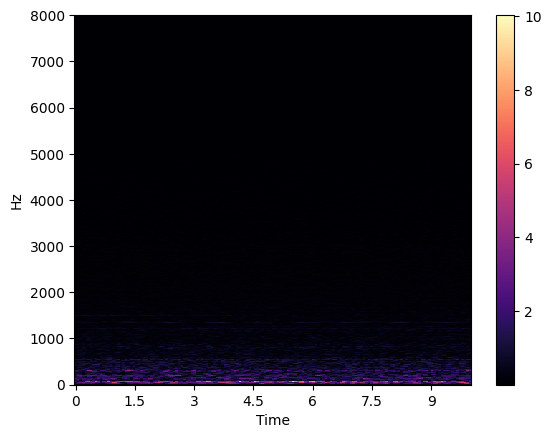

In [79]:
# Plot the spectrogram
librosa.display.specshow(audio_spectrogram, sr=samplerate, x_axis='time', y_axis='hz', hop_length=hop_length)
plt.colorbar()
plt.show()

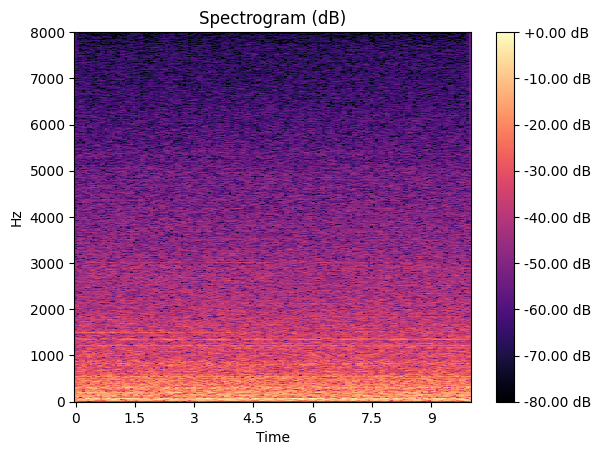

In [80]:
# Convert spectrogram amplitude to decibels
decibels_spectrogram = librosa.amplitude_to_db(audio_spectrogram, ref=np.max)
# Plot the decibel spectrogram
librosa.display.specshow(decibels_spectrogram, sr=samplerate, x_axis='time', y_axis='hz', hop_length=hop_length, cmap='magma')
plt.colorbar(format="%+.2f dB")
plt.title("Spectrogram (dB)")
plt.show()

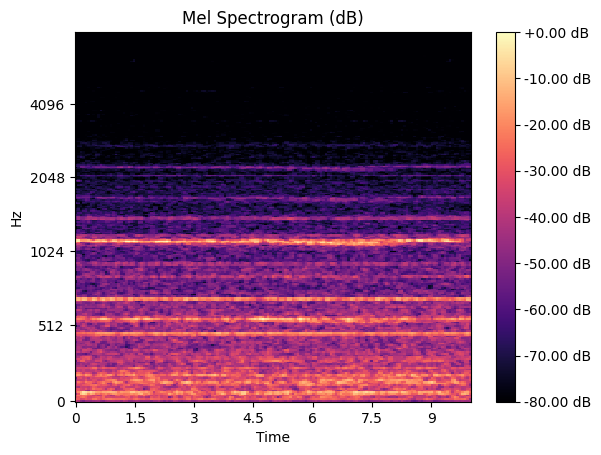

In [91]:
# Create a mel spectrogram
n_mels = 256 # number of bins
mel_signal = librosa.feature.melspectrogram(y=data, sr=samplerate, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels) # the output is a power spectrogram (**2)

mel_spectrogram = np.abs(mel_signal)
# convert to db -> need to user librosa.power_to_db since the input is a power spectrogram
mel_db_spectrogram = librosa.amplitude_to_db(mel_signal, ref=np.max)
# plot the mel spectrogram
librosa.display.specshow(mel_db_spectrogram, sr=samplerate, x_axis='time', y_axis='mel', hop_length=hop_length, cmap='magma')
plt.colorbar(format="%+.2f dB")
plt.title("Mel Spectrogram (dB)")
plt.show()


In [92]:
mel_db_spectrogram.shape

(256, 157)

In [93]:
mel_db_spectrogram

array([[-35.710453, -40.4793  , -48.245346, ..., -44.244003, -44.54457 ,
        -43.140926],
       [-26.939415, -27.598764, -33.612198, ..., -23.81725 , -30.671932,
        -44.59839 ],
       [-32.071983, -28.418919, -25.182974, ..., -34.034973, -29.925333,
        -32.10976 ],
       ...,
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ],
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ],
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ]], shape=(256, 157), dtype=float32)